# Gradient Boosting 




In [ ]:

from google.colab import drive
drive.mount('/content/drive', force_remount=False)

from pathlib import Path
PROJECT = Path('/content/drive/MyDrive/MSC THESIS')         # adjust if needed
DATA_DIR = PROJECT / 'ml_dataset' / 'data' / 'model_ready' / 'movie_success_v6'
RUN_DIR = DATA_DIR / 'colab_runs_v2'
RUN_DIR.mkdir(parents=True, exist_ok=True)


for f in ['movie_features_v6.csv',
          'movie_features_v6_synthetic.csv',
          'scene_movie_metadata_v6.csv',
          'scene_movie_metadata_v6_synthetic.csv']:
    assert (DATA_DIR / f).exists(), f'Missing: {f}'

print('Data dir:', DATA_DIR)
print('Run dir: ', RUN_DIR)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Data dir: /content/drive/MyDrive/MSC THESIS/ml_dataset/data/model_ready/movie_success_v6
Run dir:  /content/drive/MyDrive/MSC THESIS/ml_dataset/data/model_ready/movie_success_v6/colab_runs_v2


In [14]:
import warnings; warnings.filterwarnings('ignore')
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.model_selection import (
    LeaveOneOut, KFold, StratifiedKFold, GridSearchCV, cross_val_predict,
)
from sklearn.metrics import (
    mean_absolute_error, mean_squared_error, r2_score,
)
from scipy.stats import spearmanr, pearsonr

pd.set_option('display.max_columns', 80)
pd.set_option('display.width', 180)
plt.rcParams['figure.dpi'] = 100
np.random.seed(42)
print('Imports OK')

Imports OK


# Data loading

In [ ]:

real_mov  = pd.read_csv(DATA_DIR / 'movie_features_v6.csv')
syn_mov   = pd.read_csv(DATA_DIR / 'movie_features_v6_synthetic.csv')
real_meta = pd.read_csv(DATA_DIR / 'scene_movie_metadata_v6.csv')
syn_meta  = pd.read_csv(DATA_DIR / 'scene_movie_metadata_v6_synthetic.csv')

LEAKAGE_AND_OLD_TARGETS = [
    'budget_usd', 'revenue_usd', 'roi_percent', 'success_class',
    'imdb_rating', 'wom_multiplier', 'wom_multiplier_log',
]
real_mov = real_mov.drop(columns=LEAKAGE_AND_OLD_TARGETS, errors='ignore')
syn_mov  = syn_mov.drop(columns=LEAKAGE_AND_OLD_TARGETS, errors='ignore')


META_KEEP = [
    'movie_id',
    # Scene properties (will be encoded below)
    'targeted_emotion', 'clip_duration_s',
    'cut_count', 'brightness', 'motion_intensity', 'audio_loudness',
    'silence_ratio', 'music_presence', 'dialogue_density',
    'face_screen_time_ratio', 'lead_screen_time_ratio',
    # Movie metadata
    'release_year', 'genre_primary', 'genre_secondary',
    'country_of_origin', 'budget_categorical',
    # Targets (kept to extract y; not used as features)
    'imdb_rating', 'wom_multiplier', 'wom_multiplier_log',
]
real_meta_sub = real_meta[[c for c in META_KEEP if c in real_meta.columns]]
syn_meta_sub  = syn_meta[[c for c in META_KEEP if c in syn_meta.columns]]

real_mov = real_mov.merge(real_meta_sub, on='movie_id', how='left')
real_mov['is_synthetic'] = 0
syn_mov = syn_mov.merge(syn_meta_sub, on='movie_id', how='left')
syn_mov['is_synthetic'] = 1

df_all = pd.concat([real_mov, syn_mov], ignore_index=True)
print(f'Real:      {len(real_mov)} movies')
print(f'Synthetic: {len(syn_mov)} movies')
print(f'Combined:  {len(df_all)} movies × {len(df_all.columns)} columns (pre-encoding)')
print()
print('Target distributions (pre-encoding):')
display(df_all[['is_synthetic', 'imdb_rating', 'wom_multiplier_log']]
        .groupby('is_synthetic').describe().round(2))

Real:      10 movies
Synthetic: 40 movies
Combined:  50 movies × 343 columns (pre-encoding)

Target distributions (pre-encoding):


imdb_rating                                        wom_multiplier_log                                          
                   count  mean   std  min  25%   50%   75%  max              count  mean   std   min   25%   50%   75%   max
is_synthetic                                                                                                                
0                   10.0  7.41  0.73  6.5  6.8  7.45  8.02  8.5               10.0  1.77  0.64  0.75  1.28  1.88  2.21  2.73
1                   40.0  7.48  0.55  6.5  7.0  7.50  7.82  8.4               40.0  1.70  0.54  0.34  1.28  1.86  2.04  2.91

## 3 · Feature preparation

In [ ]:

DROP = {
    'movie_id', 'condition', 'n_participants',
    # Targets (cannot be features)
    'imdb_rating', 'wom_multiplier', 'wom_multiplier_log',
    # Control flag (not a feature)
    'is_synthetic',
}

df_feat = df_all.copy()

# Ordinal encoding: low / moderate / high → 1 / 2 / 3 
ORD_MAP = {'low': 1, 'moderate': 2, 'high': 3}
ORD_COLS = ['cut_count', 'brightness', 'motion_intensity', 'audio_loudness',
            'silence_ratio', 'music_presence', 'dialogue_density',
            'face_screen_time_ratio', 'lead_screen_time_ratio',
            'budget_categorical']
for c in ORD_COLS:
    if c in df_feat.columns:
        df_feat[c] = df_feat[c].map(ORD_MAP)

# One-hot encode multi-category text columns 
OH_COLS = ['targeted_emotion', 'genre_primary', 'genre_secondary', 'country_of_origin']
OH_COLS = [c for c in OH_COLS if c in df_feat.columns]
df_feat = pd.get_dummies(df_feat, columns=OH_COLS, prefix_sep='_',
                         dummy_na=False, dtype=int)

# Build feature matrix 
feature_cols = [c for c in df_feat.columns if c not in DROP]
X_all = df_feat[feature_cols].apply(pd.to_numeric, errors='coerce')
y_imdb_all = df_feat['imdb_rating'].astype(float)
y_wom_all  = df_feat['wom_multiplier_log'].astype(float)
groups_all = df_feat['movie_id'].values if 'movie_id' in df_feat.columns else np.arange(len(df_feat))
synth_mask_all = df_feat['is_synthetic'].values.astype(bool)

# Drop all-NaN columns
all_nan_cols = X_all.columns[X_all.isna().all()].tolist()
if all_nan_cols:
    print(f'Dropping {len(all_nan_cols)} all-NaN columns')
    X_all = X_all.drop(columns=all_nan_cols)

# Drop zero-variance columns
zero_var_cols = X_all.columns[X_all.std() == 0].tolist()
if zero_var_cols:
    print(f'Dropping {len(zero_var_cols)} zero-variance columns')
    X_all = X_all.drop(columns=zero_var_cols)

feature_cols = list(X_all.columns)

#Categorise final features for transparency
phys_cols = [c for c in feature_cols if c.endswith('__mean') or c.endswith('__std')]
ord_in_X  = [c for c in feature_cols if c in ORD_COLS]
oh_in_X   = [c for c in feature_cols
             if any(c.startswith(p + '_') for p in
                    ['targeted_emotion', 'genre_primary', 'genre_secondary',
                     'country_of_origin'])]
other_cols = [c for c in feature_cols
              if c not in phys_cols + ord_in_X + oh_in_X]

print(f'\nFinal feature matrix: {X_all.shape}')
print(f'  Physiological (mean/std):  {len(phys_cols):>4d}')
print(f'  Scene/movie ordinal:       {len(ord_in_X):>4d}  ({ord_in_X})')
print(f'  Scene/movie one-hot:       {len(oh_in_X):>4d}')
print(f'  Other numeric (year, dur): {len(other_cols):>4d}  ({other_cols})')
print(f'  TOTAL features:            {len(feature_cols):>4d}')


Final feature matrix: (50, 360)
  Physiological (mean/std):   320
  Scene/movie ordinal:         10  (['cut_count', 'brightness', 'motion_intensity', 'audio_loudness', 'silence_ratio', 'music_presence', 'dialogue_density', 'face_screen_time_ratio', 'lead_screen_time_ratio', 'budget_categorical'])
  Scene/movie one-hot:         28
  Other numeric (year, dur):    2  (['clip_duration_s', 'release_year'])
  TOTAL features:             360


# Evaluation helpers

In [ ]:

def regression_metrics(y_true, y_pred):
    """Compute R², MAE, RMSE, Spearman, Pearson."""
    mask = ~(np.isnan(y_pred) | np.isnan(y_true))
    yt, yp = np.asarray(y_true)[mask], np.asarray(y_pred)[mask]
    if len(yt) < 3:
        return {'n': len(yt), 'r2': np.nan, 'mae': np.nan, 'rmse': np.nan,
                'spearman': np.nan, 'pearson': np.nan}
    return {
        'n': len(yt),
        'r2': r2_score(yt, yp),
        'mae': mean_absolute_error(yt, yp),
        'rmse': np.sqrt(mean_squared_error(yt, yp)),
        'spearman': spearmanr(yt, yp).correlation,
        'pearson': pearsonr(yt, yp)[0],
    }


def loo_predict(estimator, X, y):
    """Leave-one-out cross-validated predictions."""
    loo = LeaveOneOut()
    return cross_val_predict(estimator, X, y, cv=loo, n_jobs=-1)


def kfold_predict(estimator, X, y, n_splits=5, random_state=42):
    """K-fold CV predictions (k=5 default)."""
    kf = KFold(n_splits=n_splits, shuffle=True, random_state=random_state)
    return cross_val_predict(estimator, X, y, cv=kf, n_jobs=-1)


def report(metrics, title=''):
    print(f'\n──── {title} ────')
    for k, v in metrics.items():
        if k == 'n':
            print(f'  {k:>10s}: {v}')
        else:
            print(f'  {k:>10s}: {v:.3f}' if not np.isnan(v) else f'  {k:>10s}: NaN')


def plot_pred_vs_actual(y_true, y_pred, title, ax=None):
    if ax is None:
        fig, ax = plt.subplots(figsize=(5, 5))
    mask = ~(np.isnan(y_pred) | np.isnan(y_true))
    yt, yp = np.asarray(y_true)[mask], np.asarray(y_pred)[mask]
    ax.scatter(yt, yp, alpha=0.6, s=40, edgecolor='k', linewidth=0.5)
    lo, hi = min(yt.min(), yp.min()), max(yt.max(), yp.max())
    ax.plot([lo, hi], [lo, hi], 'r--', alpha=0.5, label='y = x')
    r2 = r2_score(yt, yp)
    rho = spearmanr(yt, yp).correlation
    ax.set_xlabel('Actual')
    ax.set_ylabel('Predicted')
    ax.set_title(f'{title}\nR² = {r2:.2f}, Spearman ρ = {rho:.2f}')
    ax.legend()
    ax.grid(alpha=0.3)
    return ax

# Real-only (LOO CV, n = 10)

In [ ]:
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.inspection import permutation_importance

mask_real = ~synth_mask_all
X_real = X_all[mask_real].reset_index(drop=True)
y_imdb_real = y_imdb_all[mask_real].reset_index(drop=True)
y_wom_real = y_wom_all[mask_real].reset_index(drop=True)

def make_gbm_pipeline(learning_rate=0.1, max_iter=100, max_depth=None,
                      min_samples_leaf=20, l2_regularization=0.0):
    
    return Pipeline([
        ('model', HistGradientBoostingRegressor(
            learning_rate=learning_rate, max_iter=max_iter,
            max_depth=max_depth, min_samples_leaf=min_samples_leaf,
            l2_regularization=l2_regularization, random_state=42)),
    ])

# Baseline
pipe = make_gbm_pipeline()
y_pred = loo_predict(pipe, X_real, y_imdb_real)
metrics_real_imdb_baseline = regression_metrics(y_imdb_real, y_pred)
report(metrics_real_imdb_baseline, 'Real / IMDb / baseline')

pipe = make_gbm_pipeline()
y_pred = loo_predict(pipe, X_real, y_wom_real)
metrics_real_wom_baseline = regression_metrics(y_wom_real, y_pred)
report(metrics_real_wom_baseline, 'Real / WOM-log / baseline')


──── Real / IMDb / baseline ────
           n: 10
          r2: -0.235
         mae: 0.678
        rmse: 0.774
    spearman: -1.000
     pearson: -1.000

──── Real / WOM-log / baseline ────
           n: 10
          r2: -0.235
         mae: 0.573
        rmse: 0.671
    spearman: -1.000
     pearson: -1.000


# Tuned

In [ ]:
# REAL-ONLY: heavily constrained grid for n=10. Previous version
# overfit; we now restrict capacity strongly (max_depth less than 3,
# few iterations, higher l2_regularization).
param_grid = {
    'model__learning_rate':     [0.005, 0.01, 0.05],
    'model__max_iter':          [30, 50, 100],
    'model__max_depth':         [1, 2, 3],
    'model__min_samples_leaf':  [2, 4],
    'model__l2_regularization': [0.0, 1.0, 10.0],
}

search = GridSearchCV(make_gbm_pipeline(), param_grid,
                     cv=LeaveOneOut(), scoring='neg_mean_absolute_error',
                     n_jobs=-1, refit=True)
search.fit(X_real, y_imdb_real)
best_params_imdb_real = search.best_params_
y_pred_real_imdb_tuned = loo_predict(search.best_estimator_, X_real, y_imdb_real)
metrics_real_imdb_tuned = regression_metrics(y_imdb_real, y_pred_real_imdb_tuned)
print(f'\nBest IMDb params: {best_params_imdb_real}')
report(metrics_real_imdb_tuned, 'Real / IMDb / tuned')

search = GridSearchCV(make_gbm_pipeline(), param_grid,
                     cv=LeaveOneOut(), scoring='neg_mean_absolute_error',
                     n_jobs=-1, refit=True)
search.fit(X_real, y_wom_real)
best_params_wom_real = search.best_params_
y_pred_real_wom_tuned = loo_predict(search.best_estimator_, X_real, y_wom_real)
metrics_real_wom_tuned = regression_metrics(y_wom_real, y_pred_real_wom_tuned)
print(f'\nBest WOM params: {best_params_wom_real}')
report(metrics_real_wom_tuned, 'Real / WOM-log / tuned')


Best IMDb params: {'model__l2_regularization': 10.0, 'model__learning_rate': 0.005, 'model__max_depth': 2, 'model__max_iter': 30, 'model__min_samples_leaf': 2}

──── Real / IMDb / tuned ────
           n: 10
          r2: -0.225
         mae: 0.679
        rmse: 0.771
    spearman: -0.896
     pearson: -0.948

Best WOM params: {'model__l2_regularization': 10.0, 'model__learning_rate': 0.05, 'model__max_depth': 1, 'model__max_iter': 100, 'model__min_samples_leaf': 4}

──── Real / WOM-log / tuned ────
           n: 10
          r2: 0.245
         mae: 0.446
        rmse: 0.525
    spearman: 0.552
     pearson: 0.510


# Augmented (5-fold CV, n = 50)

In [20]:
# More reasonable param ranges for n=50.
param_grid_aug = {
    'model__learning_rate':     [0.01, 0.05, 0.1],
    'model__max_iter':          [100, 200, 400],
    'model__max_depth':         [3, 5, 7, None],
    'model__min_samples_leaf':  [4, 10, 20],
    'model__l2_regularization': [0.0, 0.1, 1.0],
}

# Baseline
pipe = make_gbm_pipeline()
y_pred_aug_imdb = kfold_predict(pipe, X_all, y_imdb_all, n_splits=5)
metrics_aug_imdb_baseline = regression_metrics(y_imdb_all, y_pred_aug_imdb)
report(metrics_aug_imdb_baseline, 'Augmented / IMDb / baseline')

pipe = make_gbm_pipeline()
y_pred_aug_wom = kfold_predict(pipe, X_all, y_wom_all, n_splits=5)
metrics_aug_wom_baseline = regression_metrics(y_wom_all, y_pred_aug_wom)
report(metrics_aug_wom_baseline, 'Augmented / WOM-log / baseline')


──── Augmented / IMDb / baseline ────
           n: 50
          r2: 0.278
         mae: 0.362
        rmse: 0.488
    spearman: 0.542
     pearson: 0.540

──── Augmented / WOM-log / baseline ────
           n: 50
          r2: -0.032
         mae: 0.445
        rmse: 0.557
    spearman: 0.186
     pearson: 0.216


In [21]:
# AUGMENTED — wider grid, includes max_leaf_nodes
param_grid_aug = {
    'model__learning_rate':     [0.01, 0.05, 0.1],
    'model__max_iter':          [50, 100, 200, 400, 800],
    'model__max_depth':         [3, 5, 7, None],
    'model__min_samples_leaf':  [4, 10, 20],
    'model__l2_regularization': [0.0, 0.1, 1.0, 10.0],
    'model__max_leaf_nodes':    [15, 31, 63],
}

search = GridSearchCV(make_gbm_pipeline(), param_grid_aug,
                     cv=KFold(n_splits=5, shuffle=True, random_state=42),
                     scoring='neg_mean_absolute_error', n_jobs=-1, refit=True)
search.fit(X_all, y_imdb_all)
best_params_imdb = search.best_params_
y_pred_aug_imdb_tuned = kfold_predict(search.best_estimator_, X_all, y_imdb_all, n_splits=5)
metrics_aug_imdb_tuned = regression_metrics(y_imdb_all, y_pred_aug_imdb_tuned)
print(f'\nBest IMDb params: {best_params_imdb}')
report(metrics_aug_imdb_tuned, 'Augmented / IMDb / tuned')

search = GridSearchCV(make_gbm_pipeline(), param_grid_aug,
                     cv=KFold(n_splits=5, shuffle=True, random_state=42),
                     scoring='neg_mean_absolute_error', n_jobs=-1, refit=True)
search.fit(X_all, y_wom_all)
best_params_wom = search.best_params_
y_pred_aug_wom_tuned = kfold_predict(search.best_estimator_, X_all, y_wom_all, n_splits=5)
metrics_aug_wom_tuned = regression_metrics(y_wom_all, y_pred_aug_wom_tuned)
print(f'\nBest WOM params: {best_params_wom}')
report(metrics_aug_wom_tuned, 'Augmented / WOM-log / tuned')


Best IMDb params: {'model__l2_regularization': 10.0, 'model__learning_rate': 0.05, 'model__max_depth': 3, 'model__max_iter': 100, 'model__max_leaf_nodes': 15, 'model__min_samples_leaf': 4}

──── Augmented / IMDb / tuned ────
           n: 50
          r2: 0.476
         mae: 0.307
        rmse: 0.416
    spearman: 0.712
     pearson: 0.690

Best WOM params: {'model__l2_regularization': 1.0, 'model__learning_rate': 0.1, 'model__max_depth': 3, 'model__max_iter': 800, 'model__max_leaf_nodes': 15, 'model__min_samples_leaf': 10}

──── Augmented / WOM-log / tuned ────
           n: 50
          r2: 0.136
         mae: 0.394
        rmse: 0.510
    spearman: 0.364
     pearson: 0.396


# Visuals

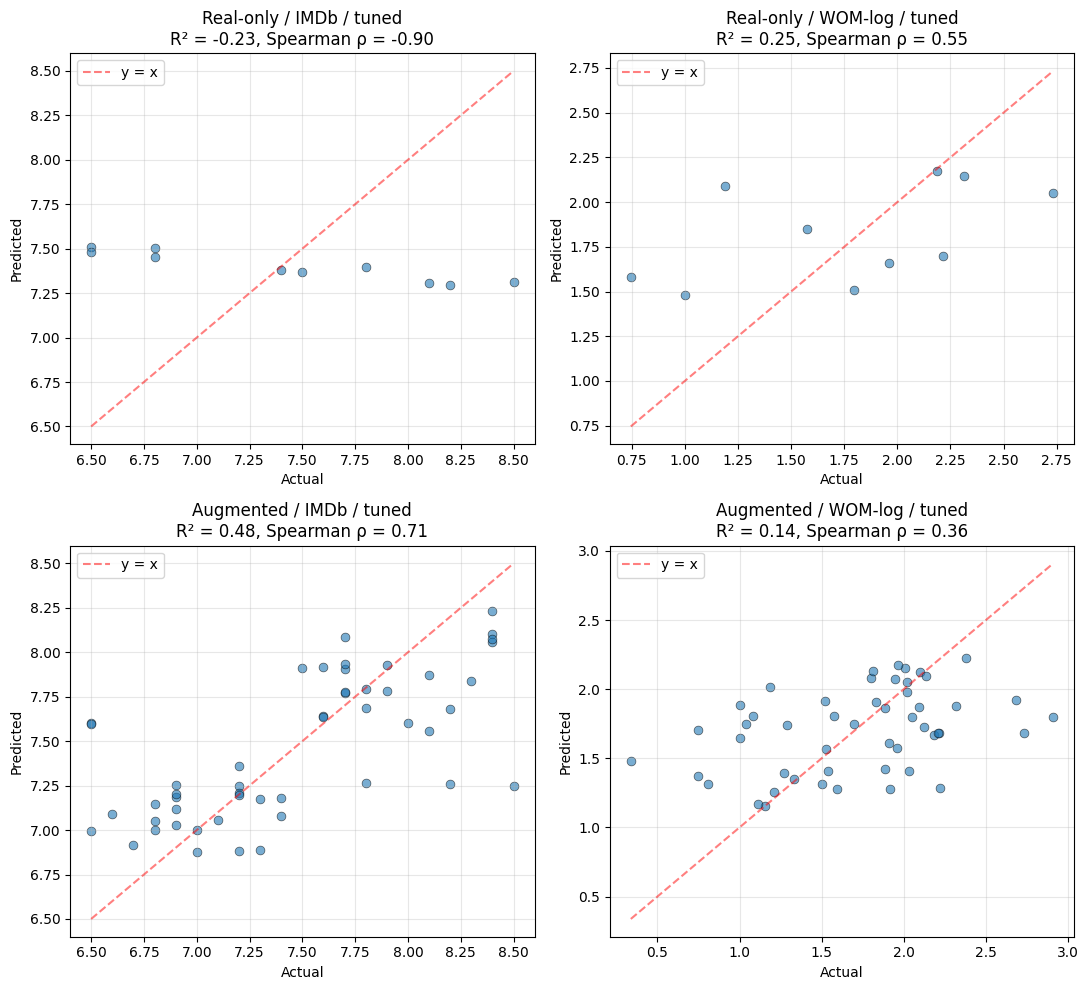

In [22]:
fig, axes = plt.subplots(2, 2, figsize=(11, 10))
plot_pred_vs_actual(y_imdb_real, y_pred_real_imdb_tuned,
                    'Real-only / IMDb / tuned', axes[0, 0])
plot_pred_vs_actual(y_wom_real, y_pred_real_wom_tuned,
                    'Real-only / WOM-log / tuned', axes[0, 1])
plot_pred_vs_actual(y_imdb_all, y_pred_aug_imdb_tuned,
                    'Augmented / IMDb / tuned', axes[1, 0])
plot_pred_vs_actual(y_wom_all, y_pred_aug_wom_tuned,
                    'Augmented / WOM-log / tuned', axes[1, 1])
plt.tight_layout()
plt.show()

# Permutation importance

Top 30 features by permutation importance:


,feature,imp_mean,imp_std
257,sr_emo_bc_disgust__std,0.1290,0.0163
256,sr_emo_bc_disgust__mean,0.1170,0.0175
60,emp_hr_reactivity__mean,0.0820,0.0130
9,eeg_alpha_asym_buildup__std,0.0669,0.0107
12,eeg_alpha_asym_mean__mean,0.0583,0.0104
221,q_neutral_max__std,0.0432,0.0067
227,q_non_neutral_fraction__std,0.0286,0.0083
230,q_sadness_max__mean,0.0226,0.0060
161,of_nose_wrinkle_onset_latency_s__std,0.0179,0.0034
70,emp_movement_std__mean,0.0162,0.0034


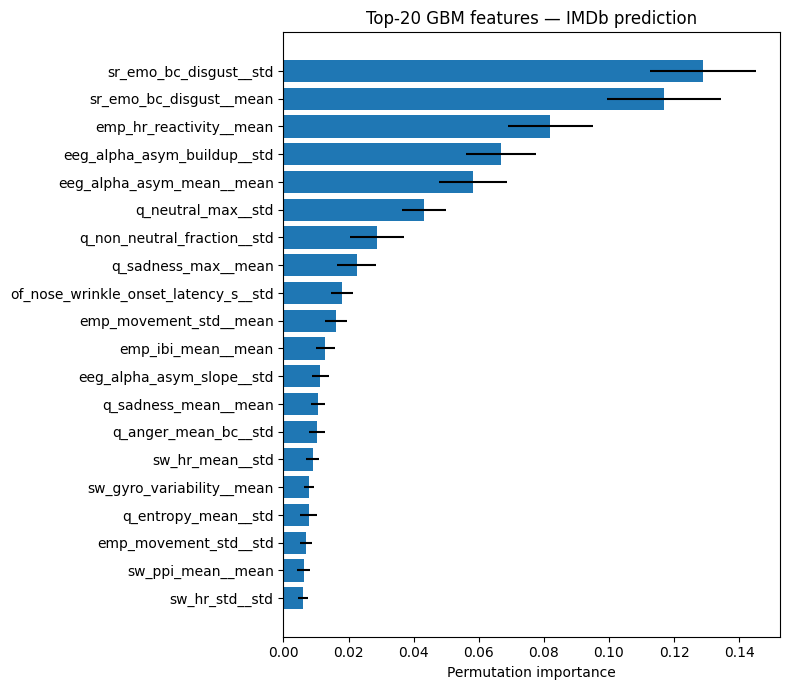

In [24]:
from sklearn.pipeline import Pipeline
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.inspection import permutation_importance

def make_gbm_pipeline(learning_rate=0.1, max_iter=100, max_depth=None,
                      min_samples_leaf=20, l2_regularization=0.0, max_leaf_nodes=31):
    # HistGradientBoosting handles NaN natively, so no imputer needed.
    return Pipeline([
        ('model', HistGradientBoostingRegressor(
            learning_rate=learning_rate, max_iter=max_iter,
            max_depth=max_depth, min_samples_leaf=min_samples_leaf,
            l2_regularization=l2_regularization, max_leaf_nodes=max_leaf_nodes,
            random_state=42)),
    ])

final_pipe = make_gbm_pipeline(**{k.replace('model__', ''): v for k, v in best_params_imdb.items()})
final_pipe.fit(X_all, y_imdb_all)

perm = permutation_importance(
    final_pipe, X_all, y_imdb_all,
    n_repeats=20, random_state=42, n_jobs=-1, scoring='neg_mean_absolute_error',
)
imp_df = (pd.DataFrame({
    'feature': feature_cols,
    'imp_mean': perm.importances_mean,
    'imp_std':  perm.importances_std,
}).sort_values('imp_mean', ascending=False))
print('Top 30 features by permutation importance:')
display(imp_df.head(30).round(4))

top = imp_df.head(20).iloc[::-1]
fig, ax = plt.subplots(figsize=(8, 7))
ax.barh(top['feature'], top['imp_mean'], xerr=top['imp_std'])
ax.set_xlabel('Permutation importance')
ax.set_title('Top-20 GBM features — IMDb prediction')
plt.tight_layout()
plt.show()

In [ ]:
# Save results
out_path = RUN_DIR / 'results_gradient_boosting.json'
results_to_save = {
    'model': 'gradient_boosting',
    'feature_count': len(feature_cols),
    'best_params_imdb': best_params_imdb,
    'best_params_wom':  best_params_wom,
    'metrics_real_imdb_baseline': metrics_real_imdb_baseline,
    'metrics_real_wom_baseline':  metrics_real_wom_baseline,
    'metrics_real_imdb_tuned':    metrics_real_imdb_tuned,
    'metrics_real_wom_tuned':     metrics_real_wom_tuned,
    'metrics_aug_imdb_baseline':  metrics_aug_imdb_baseline,
    'metrics_aug_wom_baseline':   metrics_aug_wom_baseline,
    'metrics_aug_imdb_tuned':     metrics_aug_imdb_tuned,
    'metrics_aug_wom_tuned':      metrics_aug_wom_tuned,
}
with open(out_path, 'w') as f:
    json.dump(results_to_save, f, indent=2, default=str)

print(f'\nSaved → {out_path}')


Saved → /content/drive/MyDrive/MSC THESIS/ml_dataset/data/model_ready/movie_success_v6/colab_runs_v2/results_gradient_boosting.json
